In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("Dataset_Day13.csv")

# Check missing values
print(df.isnull().sum())

# Fill missing values using median
for col in df.columns[1:-1]:      # Skip Id and Species columns
    df[col] = df[col].fillna(df[col].median())


# Remove outliers using IQR method
for col in df.columns[1:-1]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_rows = df[(df[col] < lower) | (df[col] > upper)]

    df = df.drop(outlier_rows.index)

# Display cleaned dataset
print(df.shape)
print(df.head())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
(146, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [2]:
# Group data by Species and calculate statistics
stats = df.groupby("Species").describe()

print(stats)

                   Id                                                       \
                count        mean        std    min     25%    50%     75%   
Species                                                                      
Iris-setosa      47.0   25.361702  14.885688    1.0   12.50   25.0   38.50   
Iris-versicolor  49.0   75.795918  14.575921   51.0   64.00   76.0   88.00   
Iris-virginica   50.0  125.500000  14.577380  101.0  113.25  125.5  137.75   

                       SepalLengthCm            ... PetalLengthCm       \
                   max         count      mean  ...           75%  max   
Species                                         ...                      
Iris-setosa       50.0          47.0  4.976596  ...         1.600  1.9   
Iris-versicolor  100.0          49.0  5.955102  ...         4.600  5.1   
Iris-virginica   150.0          50.0  6.588000  ...         5.875  6.9   

                PetalWidthCm                                               
          

In [3]:
from sklearn.cluster import KMeans

# Features used for clustering
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]

# Create KMeans model with 3 clusters
model = KMeans(n_clusters=3, random_state=100)

# Train model
model.fit(X)

# Store cluster numbers
df["Cluster"] = model.labels_

# Display first few rows
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


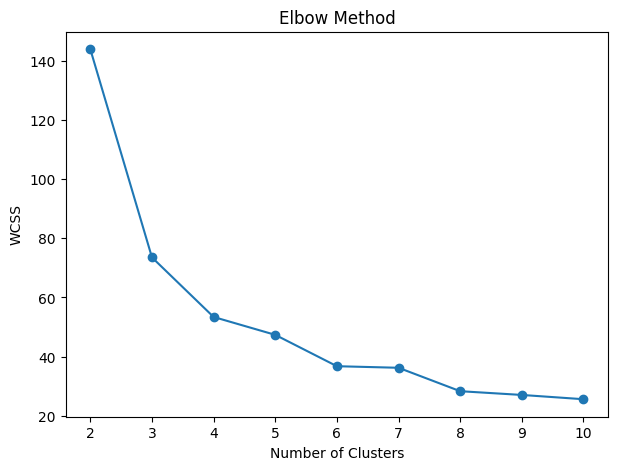

In [ ]:
#	Find the optimum cluster number based on
import matplotlib.pyplot as plt

wcss = []

# Try cluster values from 2 to 10
for i in range(2, 11):

    model = KMeans(n_clusters=i, random_state=100)

    model.fit(X)

    wcss.append(model.inertia_)

# Plot graph
plt.figure(figsize=(7,5))

plt.plot(range(2,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [5]:
from sklearn.metrics import silhouette_score

for i in range(2,11):

    model = KMeans(n_clusters=i, random_state=100)

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    print("k =", i, "Silhouette Score =", score)

k = 2 Silhouette Score = 0.6867535359684322
k = 3 Silhouette Score = 0.5541488042389832
k = 4 Silhouette Score = 0.49351598253752693
k = 5 Silhouette Score = 0.37046904228559563
k = 6 Silhouette Score = 0.37212085558612773
k = 7 Silhouette Score = 0.3262031457426147
k = 8 Silhouette Score = 0.3648508778231094
k = 9 Silhouette Score = 0.3348775618059979
k = 10 Silhouette Score = 0.30235234233669467


In [6]:
from sklearn.metrics import calinski_harabasz_score

for i in range(2,11):

    model = KMeans(n_clusters=i, random_state=100)

    labels = model.fit_predict(X)

    score = calinski_harabasz_score(X, labels)

    print("k =", i, "CH Score =", score)

k = 2 CH Score = 511.66964935550664
k = 3 CH Score = 565.5649441649146
k = 4 CH Score = 533.4664578351161
k = 5 CH Score = 452.4690415398083
k = 6 CH Score = 471.0960353029011
k = 7 CH Score = 395.81833275706805
k = 8 CH Score = 436.5286957730818
k = 9 CH Score = 397.7749955288598
k = 10 CH Score = 371.6457914166383


In [7]:
# Create final model
model = KMeans(n_clusters=3, random_state=100)

df["Cluster"] = model.fit_predict(X)

# Species distribution inside clusters
table = pd.crosstab(df["Cluster"], df["Species"])

print(table)

# Percentage distribution
percent_table = pd.crosstab(
    df["Cluster"],
    df["Species"],
    normalize="index"
) * 100

print(percent_table)

Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               47              14
1                 47                0               0
2                  0                2              36
Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                0.0        77.049180       22.950820
1              100.0         0.000000        0.000000
2                0.0         5.263158       94.736842


In [ ]:
# The optimum number of clusters was found to be 3.
# Iris-setosa forms a completely separate cluster, while Iris-versicolor and Iris-virginica show some overlap.
# Therefore, K-Means clustering was able to group the flowers effectively based on their features.